In [3]:
import os
import configparser
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import osmnx as ox
from matplotlib import font_manager

## Get data

### OSM data

Tutorial: https://williamthyer.github.io/posts/2021/4/bike_networks/

In [12]:
#set filepaths
project_root = os.path.abspath(os.getcwd())
root = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
config_file =  os.path.join(root, 'config.cfg')

# geodata for shapefiles
config = configparser.ConfigParser()
config.read(config_file)
gdata_root = config['geodata']['path']

## Load london boroughs shapefile
gdf = gpd.read_file(os.path.join(gdata_root, 'london-shapefiles\\London_Borough_Excluding_MHW.shp'))
gdf = gdf.to_crs(4326)

In [ ]:
def get_cycleways_polygon(polygon): 
    
    # Configuring osmnx
    ox.settings.useful_tags_way + ['cycleway']
        
    # Querying for roads and bike trails
    cycleways = ox.graph_from_polygon(polygon, network_type='bike', simplify=False)
    
    # Finding all non-cycleways in the network
    non_cycleways = [(u, v, k) for  u, v, k, d  in  
                     cycleways.edges(keys=True, data=True) 
                     if  not ('cycleway'  in  d  or  
                              d['highway']=='cycleway'
                              )]
   
    # Remove non-cycleways and isolated nodes
    cycleways.remove_edges_from(non_cycleways)
   
    return cycleways

In [57]:
#loop through all boroughs and calculate the ratio of roads length : cycleways length
rc_ratio_dict = {"borough": [], "ratio": []}
for borough in gdf["NAME"].unique():
    polygon = gdf[gdf["NAME"]==borough]["geometry"].iloc[0]
    cycleways = get_cycleways_polygon(polygon)
    roads =  ox.graph_from_polygon(polygon, network_type='drive', simplify=True)
    cycleway_length = ox.basic_stats(cycleways)['edge_length_total']
    roads_length = ox.basic_stats(roads)['edge_length_total']
    rc_ratio = roads_length/cycleway_length
    rc_ratio_dict["borough"].append(borough)
    rc_ratio_dict["ratio"].append(rc_ratio)

In [62]:
rc_df = pd.DataFrame(rc_ratio_dict)
rc_df

,borough,ratio
0,Kingston upon Thames,11.630736
1,Croydon,30.424770
2,Bromley,29.073859
3,Hounslow,7.803269
4,Ealing,7.223288
5,Havering,12.133115
6,Hillingdon,12.235306
7,Harrow,22.967040
8,Brent,17.530462
9,Barnet,17.691231


In [63]:
#save to csv file
rc_df.to_csv("osmnx_road_to_cycleways_ratio.csv", index=False)

### Get cycling rates

## Playground

In [ ]:
city_name = 'Lewisham'
polygon = gdf[gdf["NAME"]==city_name]["geometry"].iloc[0]
cycleways = get_cycleways_polygon(polygon)
roads =  ox.graph_from_polygon(polygon, network_type='drive', simplify=True)

In [51]:
cycleways = get_cycleways_polygon(polygon)
roads =  ox.graph_from_polygon(polygon, network_type='drive', simplify=True)

In [49]:
#Bexley
cycleways_stats = ox.basic_stats(cycleways)
roads_stats = ox.basic_stats(roads)

cycleway_length = cycleways_stats['edge_length_total']
roads_length = roads_stats['edge_length_total']

rc_ratio = roads_length/cycleway_length
rc_ratio

13.921139808794827

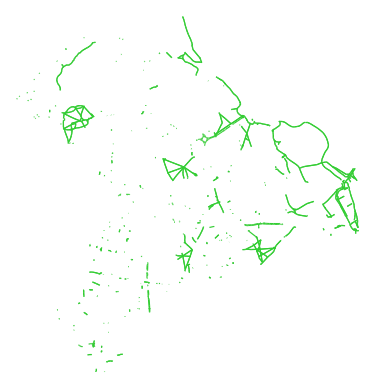

(<Figure size 640x480 with 1 Axes>, <Axes: >)

In [42]:
# Get cycleways network
# Plotting
fig, ax = plt.subplots()
ox.plot_graph(
	cycleways,
	ax=ax,
	node_size=0,
	edge_linewidth=.85,
	edge_color='limegreen')